## Import Libraries

In [21]:
import pandas as pd
import requests
import openmeteo_requests
import requests_cache
from retry_requests import retry
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Function for calling the Historical Weather API

In [22]:
def get_weather_info(row, lat_col, long_col, date_col):

  # Setup the Open-Meteo API client with cache and retry on error
  cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
  retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
  openmeteo = openmeteo_requests.Client(session = retry_session)

  latitude = row[lat_col]
  longitude = row[long_col]
  # Use the date from the FL_DATE column for the API call
  flight_date = pd.to_datetime(row[date_col]).strftime('%Y-%m-%d')
  start_date = flight_date
  end_date = flight_date


  url = "https://archive-api.open-meteo.com/v1/archive"
  params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": ["weather_code", "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min", "apparent_temperature_mean", "apparent_temperature_max", "apparent_temperature_min", "wind_speed_10m_max", "wind_gusts_10m_max", "wind_direction_10m_dominant", "shortwave_radiation_sum", "et0_fao_evapotranspiration", "sunrise", "sunset", "daylight_duration", "sunshine_duration", "precipitation_sum", "rain_sum", "snowfall_sum", "precipitation_hours"],
    "timezone": "auto",
  }
  responses = openmeteo.weather_api(url, params=params)
  response = responses[0]

  daily_data = response.Daily()


  for i in range(len(params['daily'])):
    row[params['daily'][i]] = daily_data.Variables(i).ValuesAsNumpy()

  return row

## Exploration of Delays Data Set

In [23]:
delays_df = pd.read_csv('Data/delays_by_flight.csv')

In [24]:
delays_df.head(10)

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,DEP_DEL15,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,WEATHER_DELAY
0,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,0.0,0.0,0.0,0,NaN
1,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,0.0,0.0,0.0,0,NaN
2,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,0.0,0.0,0.0,0,NaN
3,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14082,PGD,"Punta Gorda, FL",Florida,0.0,0.0,0.0,0.0,0,NaN
4,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14112,PIE,"St. Petersburg, FL",Florida,0.0,0.0,0.0,0.0,0,NaN
5,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14761,SFB,"Sanford, FL",Florida,0.0,0.0,0.0,0.0,0,NaN
6,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN
7,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN
8,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN
9,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,0.0,0.0,0.0,0,NaN


In [25]:
delays_df.columns.values

array(['FL_DATE', 'ORIGIN_AIRPORT_ID', 'ORIGIN', 'ORIGIN_CITY_NAME',
       'ORIGIN_STATE_NM', 'DEST_AIRPORT_ID', 'DEST', 'DEST_CITY_NAME',
       'DEST_STATE_NM', 'DEP_DELAY_NEW', 'DEP_DEL15', 'ARR_DELAY_NEW',
       'ARR_DEL15', 'CANCELLED', 'WEATHER_DELAY'], dtype=object)

In [26]:
delays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   FL_DATE            539747 non-null  object 
 1   ORIGIN_AIRPORT_ID  539747 non-null  int64  
 2   ORIGIN             539747 non-null  object 
 3   ORIGIN_CITY_NAME   539747 non-null  object 
 4   ORIGIN_STATE_NM    539747 non-null  object 
 5   DEST_AIRPORT_ID    539747 non-null  int64  
 6   DEST               539747 non-null  object 
 7   DEST_CITY_NAME     539747 non-null  object 
 8   DEST_STATE_NM      539747 non-null  object 
 9   DEP_DELAY_NEW      523824 non-null  float64
 10  DEP_DEL15          523824 non-null  float64
 11  ARR_DELAY_NEW      522269 non-null  float64
 12  ARR_DEL15          522269 non-null  float64
 13  CANCELLED          539747 non-null  int64  
 14  WEATHER_DELAY      98130 non-null   float64
dtypes: float64(5), int64(3), object(7)
memory usage: 61

In [27]:
delays_df.describe()


,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,DEP_DELAY_NEW,DEP_DEL15,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,WEATHER_DELAY
count,539747.000000,539747.000000,523824.000000,523824.000000,522269.000000,522269.000000,539747.000000,98130.000000
mean,12666.054390,12665.853333,14.090695,0.182619,14.218872,0.187892,0.030222,6.419770
std,1527.227187,1527.232740,53.192419,0.386354,53.054696,0.390626,0.171197,47.503613
min,10135.000000,10135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11292.000000,11292.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,12889.000000,12889.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14057.000000,14057.000000,6.000000,0.000000,7.000000,0.000000,0.000000,0.000000
max,16869.000000,16869.000000,3298.000000,1.000000,3282.000000,1.000000,1.000000,1765.000000


Majority of weather delays are 0 which affects the mean

In [28]:
mean_weather_delay = delays_df[delays_df['WEATHER_DELAY'] != 0]['WEATHER_DELAY'].mean()
print(mean_weather_delay)

81.44434389140271


Shows mean delay where there was a weather delay

In [29]:
total = delays_df.ARR_DEL15.sum()
print(total)

98130.0


This means out of 539747 flights, 98130 were over 15 minutes late to arrive

In [30]:
delays_df.ARR_DEL15.value_counts()

ARR_DEL15
0.0    424139
1.0     98130
Name: count, dtype: int64

<Axes: >

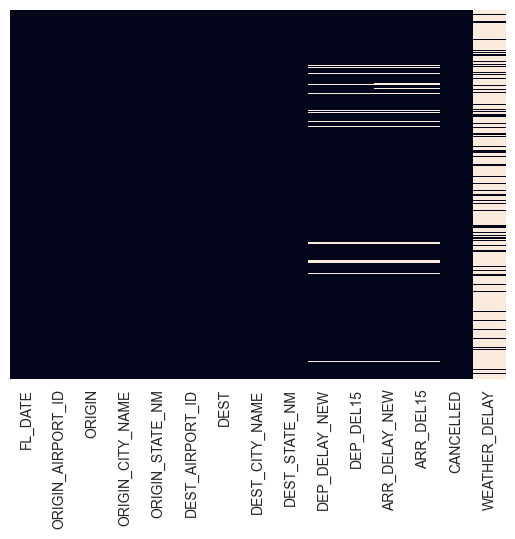

In [31]:
sns.heatmap(delays_df.isnull(),cbar=False,yticklabels=False)

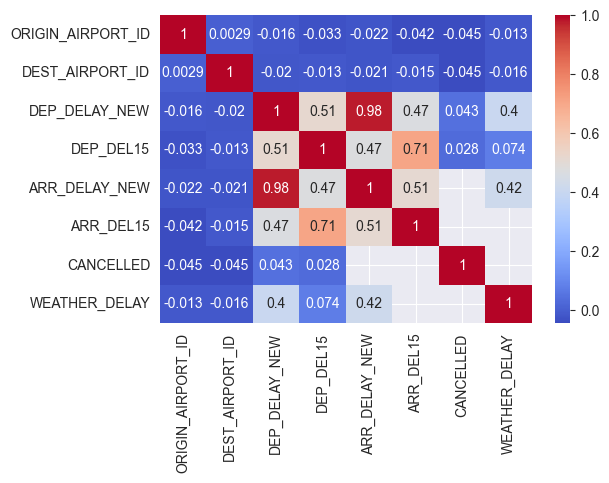

In [32]:
numeric_df = delays_df.select_dtypes(include='number')

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


Text(0.5, 1.0, 'Chart showing top 10 States for delays over 15 minutes')

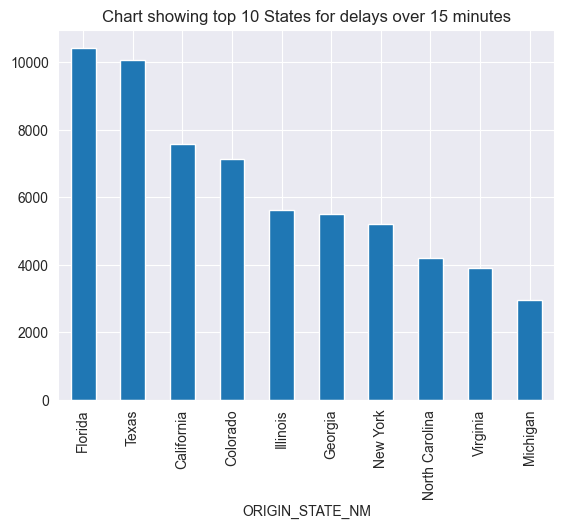

In [33]:
top_airports = delays_df.groupby('ORIGIN_STATE_NM')['ARR_DEL15'].sum().sort_values(ascending=False).head(10)
top_airports.plot(kind='bar')
plt.title('Chart showing top 10 States for delays over 15 minutes')

Object `weather` not found.


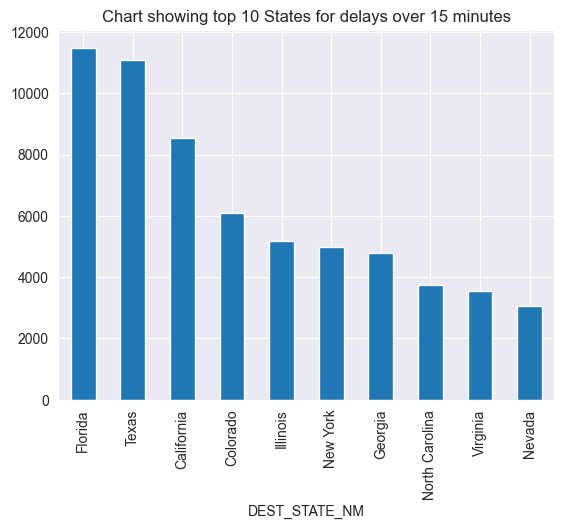

In [34]:
top_airports = delays_df.groupby('DEST_STATE_NM')['ARR_DEL15'].sum().sort_values(ascending=False).head(10)
top_airports.plot(kind='bar')
plt.title('Chart showing top 10 States for delays over 15 minutes')

Similar states are top for arrival delays when flights leave from there and arrive there- may be due to weather?

## !! Can't get this to run !!

In [35]:
weather_data_nonzero = df.loc[df['WEATHER_DELAY'] != 0, 'WEATHER_DELAY']

plt.figure(figsize=(8,4))
plt.hist(weather_data_nonzero, bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of WEATHER_DELAY (non-zero values)')
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

NameError: name 'df' is not defined

## Read the airports file

In [8]:
airports_path = 'Data/airports.csv'

In [9]:
airports_df = pd.read_csv(airports_path)

In [ ]:
airports_df.head(10)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
5,ACK,Nantucket Memorial Airport,Nantucket,MA,USA,41.25305,-70.06018
6,ACT,Waco Regional Airport,Waco,TX,USA,31.61129,-97.23052
7,ACV,Arcata Airport,Arcata/Eureka,CA,USA,40.97812,-124.10862
8,ACY,Atlantic City International Airport,Atlantic City,NJ,USA,39.45758,-74.57717
9,ADK,Adak Airport,Adak,AK,USA,51.87796,-176.64603


## Merge the delays data with the airports data

### Origin

In [ ]:
overall_df_merged = delays_df.merge(airports_df, left_on='ORIGIN', right_on='IATA_CODE', how='left')

In [ ]:
overall_df_merged.head(10)

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,ARR_DEL15,CANCELLED,WEATHER_DELAY,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
1,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
2,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
3,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14082,PGD,"Punta Gorda, FL",Florida,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
4,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14112,PIE,"St. Petersburg, FL",Florida,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
5,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14761,SFB,"Sanford, FL",Florida,0.0,...,0.0,0,NaN,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.4404
6,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819
7,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819
8,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819
9,01/01/2025 00:00,10136,ABI,"Abilene, TX",Texas,11298,DFW,"Dallas/Fort Worth, TX",Texas,0.0,...,0.0,0,NaN,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.6819


### Destination

In [ ]:
overall_df_merged = overall_df_merged.merge(airports_df, left_on='DEST', right_on='IATA_CODE', how='left', suffixes=('_ORIGIN', '_DEST'))

In [ ]:
overall_df_merged

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,COUNTRY_ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN,IATA_CODE_DEST,AIRPORT_DEST,CITY_DEST,STATE_DEST,COUNTRY_DEST,LATITUDE_DEST,LONGITUDE_DEST
0,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,USA,40.65236,-75.4404,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
1,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,USA,40.65236,-75.4404,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
2,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,11057,CLT,"Charlotte, NC",North Carolina,0.0,...,USA,40.65236,-75.4404,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14082,PGD,"Punta Gorda, FL",Florida,0.0,...,USA,40.65236,-75.4404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01/01/2025 00:00,10135,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,14112,PIE,"St. Petersburg, FL",Florida,0.0,...,USA,40.65236,-75.4404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539742,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,11292,DEN,"Denver, CO",Colorado,20.0,...,NaN,NaN,NaN,DEN,Denver International Airport,Denver,CO,USA,39.85841,-104.66700
539743,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,11292,DEN,"Denver, CO",Colorado,89.0,...,NaN,NaN,NaN,DEN,Denver International Airport,Denver,CO,USA,39.85841,-104.66700
539744,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,11292,DEN,"Denver, CO",Colorado,116.0,...,NaN,NaN,NaN,DEN,Denver International Airport,Denver,CO,USA,39.85841,-104.66700
539745,1/31/2025 12:00:00 AM,16869,XWA,"Williston, ND",North Dakota,13487,MSP,"Minneapolis, MN",Minnesota,0.0,...,NaN,NaN,NaN,MSP,Minneapolis-Saint Paul International Airport,Minneapolis,MN,USA,44.88055,-93.21692


## Filter the dataset to a manageable size for the historical weather API

In [ ]:
overall_df_merged_delayed = overall_df_merged[overall_df_merged['ARR_DEL15'] == 1.0]

In [ ]:
overall_df_merged_delayed.shape

(98130, 29)

In [ ]:
overall_df_merged_delayed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98130 entries, 20 to 539744
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            98130 non-null  object 
 1   ORIGIN_AIRPORT_ID  98130 non-null  int64  
 2   ORIGIN             98130 non-null  object 
 3   ORIGIN_CITY_NAME   98130 non-null  object 
 4   ORIGIN_STATE_NM    98130 non-null  object 
 5   DEST_AIRPORT_ID    98130 non-null  int64  
 6   DEST               98130 non-null  object 
 7   DEST_CITY_NAME     98130 non-null  object 
 8   DEST_STATE_NM      98130 non-null  object 
 9   DEP_DELAY_NEW      98130 non-null  float64
 10  DEP_DEL15          98130 non-null  float64
 11  ARR_DELAY_NEW      98130 non-null  float64
 12  ARR_DEL15          98130 non-null  float64
 13  CANCELLED          98130 non-null  int64  
 14  WEATHER_DELAY      98130 non-null  float64
 15  IATA_CODE_ORIGIN   97008 non-null  object 
 16  AIRPORT_ORIGIN     97008 

In [ ]:
overall_df_merged_delayed = overall_df_merged_delayed.dropna()

In [ ]:
overall_df_merged_delayed.shape

(95787, 29)

In [ ]:
overall_df_merged_delayed = overall_df_merged_delayed[overall_df_merged_delayed['ORIGIN_STATE_NM'] == 'Florida']

In [ ]:
overall_df_merged_delayed.shape

(9883, 29)

In [ ]:
overall_df_merged_delayed.head(10)

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,COUNTRY_ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN,IATA_CODE_DEST,AIRPORT_DEST,CITY_DEST,STATE_DEST,COUNTRY_DEST,LATITUDE_DEST,LONGITUDE_DEST
3256,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,178.0,...,USA,29.17992,-81.05806,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
6171,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,33.0,...,USA,24.55611,-81.75956,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
6172,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,55.0,...,USA,24.55611,-81.75956,CLT,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
6174,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,70.0,...,USA,24.55611,-81.75956,DCA,Ronald Reagan Washington National Airport,Arlington,VA,USA,38.85208,-77.03772
6182,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,28.0,...,USA,24.55611,-81.75956,MIA,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
6187,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,14100,PHL,"Philadelphia, PA",Pennsylvania,32.0,...,USA,24.55611,-81.75956,PHL,Philadelphia International Airport,Philadelphia,PA,USA,39.87195,-75.24114
6265,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10397,ATL,"Atlanta, GA",Georgia,0.0,...,USA,26.07258,-80.15275,ATL,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,USA,33.64044,-84.42694
6276,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10397,ATL,"Atlanta, GA",Georgia,243.0,...,USA,26.07258,-80.15275,ATL,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,USA,33.64044,-84.42694
6279,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10431,AVL,"Asheville, NC",North Carolina,75.0,...,USA,26.07258,-80.15275,AVL,Asheville Regional Airport,Asheville,NC,USA,35.43619,-82.54181
6280,01/01/2025 00:00,11697,FLL,"Fort Lauderdale, FL",Florida,10431,AVL,"Asheville, NC",North Carolina,291.0,...,USA,26.07258,-80.15275,AVL,Asheville Regional Airport,Asheville,NC,USA,35.43619,-82.54181


## Call the historical weather API for the Florida data

### Origin Data

In [ ]:
grouped_date_origin = overall_df_merged_delayed[['FL_DATE', 'ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN']].drop_duplicates()

In [ ]:
grouped_date_origin

,FL_DATE,ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN
3256,01/01/2025 00:00,DAB,29.17992,-81.05806
6171,01/01/2025 00:00,EYW,24.55611,-81.75956
6265,01/01/2025 00:00,FLL,26.07258,-80.15275
7804,01/01/2025 00:00,JAX,30.49406,-81.68786
9683,01/01/2025 00:00,MCO,28.42889,-81.31603
...,...,...,...,...
536745,1/31/2025 12:00:00 AM,RSW,26.53617,-81.75517
539018,1/31/2025 12:00:00 AM,SRQ,27.39533,-82.55411
539288,1/31/2025 12:00:00 AM,TLH,30.39653,-84.35033
539311,1/31/2025 12:00:00 AM,TPA,27.97547,-82.53325


#### API was called and data saved to avoid hitting API limit and needing to run every time. Lines of code are commented out so that calling thr API doesn't auto run

In [ ]:
# grouped_date_origin = grouped_date_origin.apply(get_weather_info, axis=1, args=('LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN', 'FL_DATE'))

In [ ]:
# grouped_date_origin.to_csv('Data/grouped_date_origin_weather_florida.csv')

In [10]:
grouped_date_origin = pd.read_csv('Data/grouped_date_origin_weather_florida.csv')

In [11]:
grouped_date_origin

,Unnamed: 0,FL_DATE,ORIGIN,LATITUDE_ORIGIN,LONGITUDE_ORIGIN,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,...,shortwave_radiation_sum,et0_fao_evapotranspiration,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours
0,3256,01/01/2025 00:00,DAB,29.17992,-81.05806,[3.],[16.194],[18.7565],[12.0065],[15.587325],...,[14.54],[2.298343],0,0,[37144.996],[33252.48],[0.],[0.],[0.],[0.]
1,6171,01/01/2025 00:00,EYW,24.55611,-81.75956,[3.],[21.925499],[23.163],[21.163],[23.675394],...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
2,6265,01/01/2025 00:00,FLL,26.07258,-80.15275,[51.],[21.942917],[25.5325],[19.432499],[24.044882],...,[15.16],[2.8054278],0,0,[37966.69],[33436.668],[0.1],[0.1],[0.],[1.]
3,7804,01/01/2025 00:00,JAX,30.49406,-81.68786,[1.],[13.960167],[18.1435],[9.4935],[11.701987],...,[14.08],[2.4897807],0,0,[36801.066],[32884.55],[0.],[0.],[0.],[0.]
4,9683,01/01/2025 00:00,MCO,28.42889,-81.31603,[3.],[17.906748],[20.863],[13.513],[17.813602],...,[14.67],[2.5929782],0,0,[37350.656],[33200.9],[0.],[0.],[0.],[0.]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,536745,1/31/2025 12:00:00 AM,RSW,26.53617,-81.75517,[3.],[20.575748],[27.4195],[16.119501],[21.958168],...,[17.49],[3.2531807],0,0,[39404.945],[36470.957],[0.],[0.],[0.],[0.]
403,539018,1/31/2025 12:00:00 AM,SRQ,27.39533,-82.55411,[3.],[17.158335],[19.1],[15.55],[17.094687],...,[17.29],[2.3360596],0,0,[39249.164],[35991.035],[0.],[0.],[0.],[0.]
404,539288,1/31/2025 12:00:00 AM,TLH,30.39653,-84.35033,[61.],[18.007084],[24.83],[12.93],[17.83943],...,[13.94],[2.5202544],0,0,[38670.094],[27814.408],[2.8999999],[2.8999999],[0.],[4.]
405,539311,1/31/2025 12:00:00 AM,TPA,27.97547,-82.53325,[1.],[19.701584],[25.437],[15.787001],[20.1602],...,[17.07],[3.0906415],0,0,[39143.977],[35814.793],[0.],[0.],[0.],[0.]


### Destination Data

In [ ]:
grouped_date_destination = overall_df_merged_delayed[['FL_DATE', 'DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST']].drop_duplicates()

In [ ]:
grouped_date_destination

,FL_DATE,DEST,LATITUDE_DEST,LONGITUDE_DEST
3256,01/01/2025 00:00,CLT,35.21401,-80.94313
6174,01/01/2025 00:00,DCA,38.85208,-77.03772
6182,01/01/2025 00:00,MIA,25.79325,-80.29056
6187,01/01/2025 00:00,PHL,39.87195,-75.24114
6265,01/01/2025 00:00,ATL,33.64044,-84.42694
...,...,...,...,...
539367,1/31/2025 12:00:00 AM,CMH,39.99799,-82.89188
539414,1/31/2025 12:00:00 AM,FLL,26.07258,-80.15275
539429,1/31/2025 12:00:00 AM,IND,39.71733,-86.29438
539441,1/31/2025 12:00:00 AM,LAS,36.08036,-115.15233


#### API was called and data saved to avoid hitting API limit and needing to run every time. Lines of code are commented out so that calling thr API doesn't auto run

In [12]:
# grouped_date_destination = grouped_date_destination.apply(get_weather_info, axis=1, args=('LATITUDE_DEST', 'LONGITUDE_DEST', 'FL_DATE'))

In [13]:
# grouped_date_destination

In [ ]:
# grouped_date_destination.to_csv('Data/grouped_date_destination_weather_florida.csv')

In [14]:
grouped_date_destination = pd.read_csv('Data/grouped_date_destination_weather_florida.csv')

In [ ]:
grouped_date_destination

,Unnamed: 0,FL_DATE,DEST,LATITUDE_DEST,LONGITUDE_DEST,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,...,shortwave_radiation_sum,et0_fao_evapotranspiration,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours
0,3256,01/01/2025 00:00,CLT,35.21401,-80.94313,[1.],[7.935001],[11.085],[4.785],[3.5809011],...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
1,6174,01/01/2025 00:00,DCA,38.85208,-77.03772,[2.],[6.8800006],[8.842501],[4.1925],[2.3371618],...,[7.69],[1.5064157],0,0,[34233.156],[30449.094],[0.],[0.],[0.],[0.]
2,6182,01/01/2025 00:00,MIA,25.79325,-80.29056,[3.],[21.935087],[25.345499],[18.9455],[24.452215],...,[15.11],[2.6905723],0,0,[38037.36],[33106.91],[0.],[0.],[0.],[0.]
3,6187,01/01/2025 00:00,PHL,39.87195,-75.24114,[3.],[7.072333],[10.089],[4.139],[2.6699219],...,[6.68],[1.3925666],0,0,[33863.1],[25166.607],[0.],[0.],[0.],[0.]
4,6265,01/01/2025 00:00,ATL,33.64044,-84.42694,[3.],[6.600416],[10.0525],[3.4025],[2.3100054],...,[10.99],[1.7924072],0,0,[35896.18],[32267.57],[0.],[0.],[0.],[0.]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1888,539367,1/31/2025 12:00:00 AM,CMH,39.99799,-82.89188,[63.],[6.570167],[12.141],[3.141],[3.5331576],...,[2.76],[0.3965713],0,0,[36547.938],[8193.414],[8.9000025],[8.9000025],[0.],[17.]
1889,539414,1/31/2025 12:00:00 AM,FLL,26.07258,-80.15275,[3.],[23.111666],[25.832499],[21.0325],[24.062616],...,[16.81],[3.6223025],0,0,[39494.75],[36659.848],[0.],[0.],[0.],[0.]
1890,539429,1/31/2025 12:00:00 AM,IND,39.71733,-86.29438,[51.],[6.9670835],[13.002501],[2.9524999],[3.8337395],...,[6.66],[0.95089],0,0,[36618.566],[14600.253],[1.6000001],[1.6000001],[0.],[11.]
1891,539441,1/31/2025 12:00:00 AM,LAS,36.08036,-115.15233,[3.],[8.203334],[14.2325],[1.6825],[4.8586235],...,[13.5],[1.9828184],0,0,[37483.805],[32766.797],[0.],[0.],[0.],[0.]


## Merge API data for origin and destination airports to the main florida dataset

In [ ]:
overall_df_merged_delayed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9883 entries, 3256 to 539684
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   FL_DATE            9883 non-null   object 
 1   ORIGIN_AIRPORT_ID  9883 non-null   int64  
 2   ORIGIN             9883 non-null   object 
 3   ORIGIN_CITY_NAME   9883 non-null   object 
 4   ORIGIN_STATE_NM    9883 non-null   object 
 5   DEST_AIRPORT_ID    9883 non-null   int64  
 6   DEST               9883 non-null   object 
 7   DEST_CITY_NAME     9883 non-null   object 
 8   DEST_STATE_NM      9883 non-null   object 
 9   DEP_DELAY_NEW      9883 non-null   float64
 10  DEP_DEL15          9883 non-null   float64
 11  ARR_DELAY_NEW      9883 non-null   float64
 12  ARR_DEL15          9883 non-null   float64
 13  CANCELLED          9883 non-null   int64  
 14  WEATHER_DELAY      9883 non-null   float64
 15  IATA_CODE_ORIGIN   9883 non-null   object 
 16  AIRPORT_ORIGIN     9883 

In [ ]:
grouped_date_origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   407 non-null    int64  
 1   FL_DATE                      407 non-null    object 
 2   ORIGIN                       407 non-null    object 
 3   LATITUDE_ORIGIN              407 non-null    float64
 4   LONGITUDE_ORIGIN             407 non-null    float64
 5   weather_code                 407 non-null    object 
 6   temperature_2m_mean          407 non-null    object 
 7   temperature_2m_max           407 non-null    object 
 8   temperature_2m_min           407 non-null    object 
 9   apparent_temperature_mean    407 non-null    object 
 10  apparent_temperature_max     407 non-null    object 
 11  apparent_temperature_min     407 non-null    object 
 12  wind_speed_10m_max           407 non-null    object 
 13  wind_gusts_10m_max  

In [96]:
florida_delays_weather_df = overall_df_merged_delayed.merge(grouped_date_origin, left_on=['FL_DATE', 'ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN'], right_on=['FL_DATE', 'ORIGIN', 'LATITUDE_ORIGIN', 'LONGITUDE_ORIGIN'], how='left')

In [97]:
florida_delays_weather_df

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,shortwave_radiation_sum,et0_fao_evapotranspiration,sunrise,sunset,daylight_duration,sunshine_duration,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours
0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,178.0,...,[14.54],[2.298343],0,0,[37144.996],[33252.48],[0.],[0.],[0.],[0.]
1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,33.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,55.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,70.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,28.0,...,[15.61],[2.302377],0,0,[38333.793],[34172.516],[0.],[0.],[0.],[0.]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9878,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14747,SEA,"Seattle, WA",Washington,7.0,...,[17.07],[3.0906415],0,0,[39143.977],[35814.793],[0.],[0.],[0.],[0.]
9879,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14843,SJU,"San Juan, PR",Puerto Rico,16.0,...,[17.07],[3.0906415],0,0,[39143.977],[35814.793],[0.],[0.],[0.],[0.]
9880,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14843,SJU,"San Juan, PR",Puerto Rico,32.0,...,[17.07],[3.0906415],0,0,[39143.977],[35814.793],[0.],[0.],[0.],[0.]
9881,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14843,SJU,"San Juan, PR",Puerto Rico,266.0,...,[17.07],[3.0906415],0,0,[39143.977],[35814.793],[0.],[0.],[0.],[0.]


In [98]:
florida_delays_weather_df = florida_delays_weather_df.merge(grouped_date_destination, left_on=['FL_DATE', 'DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST'], right_on=['FL_DATE', 'DEST', 'LATITUDE_DEST', 'LONGITUDE_DEST'], how='left', suffixes=['_ORIGIN', '_DEST'])

In [99]:
florida_delays_weather_df

,FL_DATE,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_NM,DEST_AIRPORT_ID,DEST,DEST_CITY_NAME,DEST_STATE_NM,DEP_DELAY_NEW,...,shortwave_radiation_sum_DEST,et0_fao_evapotranspiration_DEST,sunrise_DEST,sunset_DEST,daylight_duration_DEST,sunshine_duration_DEST,precipitation_sum_DEST,rain_sum_DEST,snowfall_sum_DEST,precipitation_hours_DEST
0,01/01/2025 00:00,11252,DAB,"Daytona Beach, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,178.0,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
1,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,33.0,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
2,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11057,CLT,"Charlotte, NC",North Carolina,55.0,...,[11.43],[2.2345884],0,0,[35426.99],[32053.158],[0.],[0.],[0.],[0.]
3,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,11278,DCA,"Washington, DC",Virginia,70.0,...,[7.69],[1.5064157],0,0,[34233.156],[30449.094],[0.],[0.],[0.],[0.]
4,01/01/2025 00:00,11624,EYW,"Key West, FL",Florida,13303,MIA,"Miami, FL",Florida,28.0,...,[15.11],[2.6905723],0,0,[38037.36],[33106.91],[0.],[0.],[0.],[0.]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9878,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14747,SEA,"Seattle, WA",Washington,7.0,...,[2.26],[0.49941283],0,0,[34428.723],[0.],[19.399998],[19.399998],[0.],[21.]
9879,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14843,SJU,"San Juan, PR",Puerto Rico,16.0,...,[16.43],[4.1093216],0,0,[40797.902],[37456.51],[6.7],[6.7],[0.],[14.]
9880,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14843,SJU,"San Juan, PR",Puerto Rico,32.0,...,[16.43],[4.1093216],0,0,[40797.902],[37456.51],[6.7],[6.7],[0.],[14.]
9881,1/31/2025 12:00:00 AM,15304,TPA,"Tampa, FL",Florida,14843,SJU,"San Juan, PR",Puerto Rico,266.0,...,[16.43],[4.1093216],0,0,[40797.902],[37456.51],[6.7],[6.7],[0.],[14.]


In [100]:
florida_delays_weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9883 entries, 0 to 9882
Data columns (total 71 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   FL_DATE                             9883 non-null   object 
 1   ORIGIN_AIRPORT_ID                   9883 non-null   int64  
 2   ORIGIN                              9883 non-null   object 
 3   ORIGIN_CITY_NAME                    9883 non-null   object 
 4   ORIGIN_STATE_NM                     9883 non-null   object 
 5   DEST_AIRPORT_ID                     9883 non-null   int64  
 6   DEST                                9883 non-null   object 
 7   DEST_CITY_NAME                      9883 non-null   object 
 8   DEST_STATE_NM                       9883 non-null   object 
 9   DEP_DELAY_NEW                       9883 non-null   float64
 10  DEP_DEL15                           9883 non-null   float64
 11  ARR_DELAY_NEW                       9883 no

In [101]:
florida_delays_weather_df.drop(['Unnamed: 0_ORIGIN', 'Unnamed: 0_DEST', 'IATA_CODE_ORIGIN', 'IATA_CODE_DEST'], axis=1, inplace=True)

###### commented out to not be overwritten

In [102]:
# florida_delays_weather_df.to_csv('Data/florida_delays_weather_data.csv')